# Car Damage Prediction

In [2]:
# Importing Libraries 
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
import time 
import torchvision.models as models 
from matplotlib import pyplot as plt 


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Load Data

In [8]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
dataset_path = r"C:\Users\pksju\Desktop\code\Car_damage_prediction\dataset"

dataset = datasets.ImageFolder(dataset_path, transform=image_transforms)
len(dataset)

2296

In [10]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [11]:
num_classes = len(dataset.classes)
num_classes

6

In [12]:
2300*0.75

1725.0

In [14]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size
train_size, val_size

(1722, 574)

In [15]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [17]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [26]:
labels[6]

tensor(0)

In [27]:
images[6].shape

torch.Size([3, 224, 224])

In [28]:
images[6].permute(1, 2, 0).shape  

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.1519828].


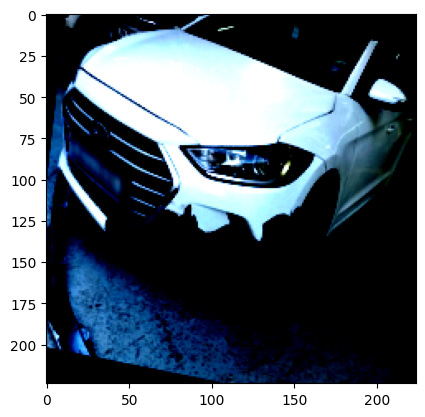

In [29]:
plt.imshow(images[6].permute(1, 2, 0)) # Re-arranging dimension to display the image 
plt.show()

### Model 1: CNN

In [32]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=1, stride=1, padding=1), #  (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16,112,112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [33]:
# Instantiate the model, Loss function, and optimzer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [34]:
len(train_loader.dataset)

1722

In [36]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")


            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f" => Validation Accuracy: {100 * correct / total:.2f}% <=")

    end = time.time()
    print(f"Execution time: {end - start} seconds")
    return all_labels, all_predictions

In [38]:
train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.19
Batch: 20, Epoch: 1, Loss: 1.43
Batch: 30, Epoch: 1, Loss: 1.40
Batch: 40, Epoch: 1, Loss: 0.98
Batch: 50, Epoch: 1, Loss: 1.58
Epoch [1/5], Avg Loss: 1.3568
 => Validation Accuracy: 47.74% <=
Batch: 10, Epoch: 2, Loss: 1.12
Batch: 20, Epoch: 2, Loss: 1.58
Batch: 30, Epoch: 2, Loss: 1.36
Batch: 40, Epoch: 2, Loss: 1.13
Batch: 50, Epoch: 2, Loss: 1.17
Epoch [2/5], Avg Loss: 1.1913
 => Validation Accuracy: 49.30% <=
Batch: 10, Epoch: 3, Loss: 0.69
Batch: 20, Epoch: 3, Loss: 1.01
Batch: 30, Epoch: 3, Loss: 0.98
Batch: 40, Epoch: 3, Loss: 1.09
Batch: 50, Epoch: 3, Loss: 0.97
Epoch [3/5], Avg Loss: 1.0527
 => Validation Accuracy: 49.48% <=
Batch: 10, Epoch: 4, Loss: 1.08
Batch: 20, Epoch: 4, Loss: 0.90
Batch: 30, Epoch: 4, Loss: 0.99
Batch: 40, Epoch: 4, Loss: 1.00
Batch: 50, Epoch: 4, Loss: 0.92
Epoch [4/5], Avg Loss: 0.9772
 => Validation Accuracy: 54.88% <=
Batch: 10, Epoch: 5, Loss: 1.08
Batch: 20, Epoch: 5, Loss: 0.73
Batch: 30, Epoch: 5, Loss: 0.65
Batc

([np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(5),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(4),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64